In [45]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [103]:
# step-0: spread out some points at random
num_points = 50
R = 100
step_size = 1.  # how much they move in each time step
N_dim = 1  # in how many dims are we working?
N_steps = 1000

np.random.seed(2)
pos = np.sort(R*np.random.random(num_points))
y = np.zeros_like(pos)

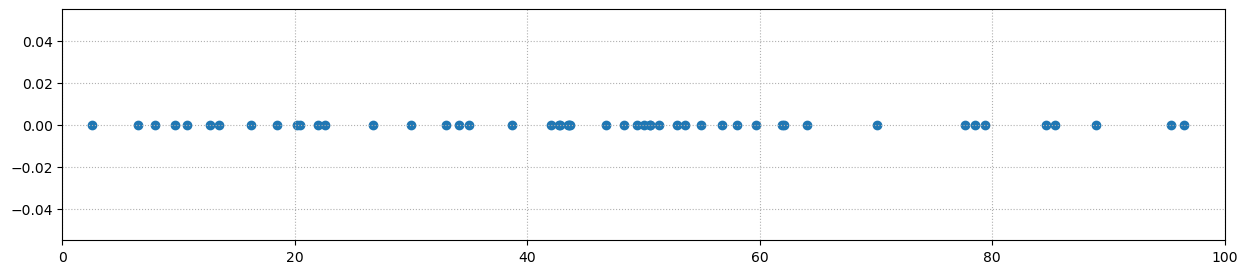

In [88]:
def plot_positions(pos):
    fig, ax = plt.subplots(figsize=(15,3))
    ax.scatter(pos, y)
    ax.grid(ls=":")
    ax.set_xlim(0, R)

plot_positions(pos)

In [100]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)
    for i, posN in enumerate(pos):
        dist = pos - posN
        
        dist_left = dist[dist < 0]
        dist_right = dist[dist > 0]
        
        F_net[i] = np.sum(np.abs(1 / dist_left**N_dim)) - np.sum(np.abs(1 / dist_right**N_dim))
        
    return F_net

In [108]:
for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps*50))
    
    new_pos = pos + effective_step_size * compute_net_force(pos)
    new_pos = np.clip(new_pos, a_min=0, a_max=R)  # respect the boundaries

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 179.44it/s]


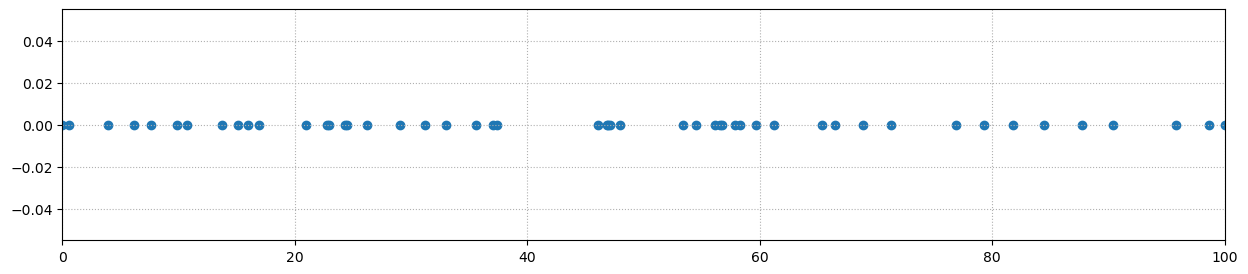

In [109]:
plot_positions(new_pos)